# WEEK -05: LOGISTIC REGRESSION AND STOCHASTIC GRADIENT DESCENT (SGD)

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report

1.<br>Create a CSV file for the above training data and write a Python function program to find the fitted linear
regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with
your program. Compute the log loss, MSE and RMSE. Plot the graph Daughter height (Y-axis) vs Mother
height (X-axis) with blue colour. Also, plot the line of best fit with red colour. Predict her daughter’s height
with given a new mother height as 63. Plot the graph of error in y-axis and iteration in x-axis with 4 epochs
(6x4=24 iterations).

In [141]:
data = {
    'mother_height_x': [60, 62, 64, 65, 67, 68],
    'daughter_height_y': [61, 63, 65, 66, 68, 70]
}
df = pd.DataFrame(data)
df.to_csv('heights_data.csv', index=False)
print("CSV file 'heights_data.csv' created successfully.")

CSV file 'heights_data.csv' created successfully.


In [142]:
df = pd.read_csv('heights_data.csv')
X = df['mother_height_x'].values
Y = df['daughter_height_y'].values
n_samples = len(X)

epochs = 4
learning_rate = 0.0001
w = 0.0
b = 0.0 

history_iterations = []
history_errors = []
iteration_count = 0

for epoch in range(epochs):
    for i in range(n_samples):
        iteration_count += 1
        xi = X[i]
        yi = Y[i]
        
        y_pred = w * xi + b
        
        current_preds = w * X + b
        current_mse = np.mean((Y - current_preds) ** 2)
        
        history_iterations.append(iteration_count)
        history_errors.append(current_mse)
        
        dw = -2 * (yi - y_pred) * xi
        db = -2 * (yi - y_pred)
        w -= learning_rate * dw
        b -= learning_rate * db


lr_model = LinearRegression()
X_reshaped = X.reshape(-1, 1)
lr_model.fit(X_reshaped, Y)

sklearn_w = lr_model.coef_[0]
sklearn_b = lr_model.intercept_


gd_preds = w * X + b
sklearn_preds = lr_model.predict(X_reshaped)

gd_mse = mean_squared_error(Y, gd_preds)
gd_rmse = np.sqrt(gd_mse)

sklearn_mse = mean_squared_error(Y, sklearn_preds)
sklearn_rmse = np.sqrt(sklearn_mse)


new_mother_height = 63
pred_gd = w * new_mother_height + b
pred_sklearn = lr_model.predict([[new_mother_height]])[0]

print(f"RESULTS")
print(f"Gradient Descent, Slope-(w): {w:.4f}, Intercept-(b): {b:.4f}")
print(f"Sklearn Model,    Slope-(w): {sklearn_w:.4f}, Intercept-(b): {sklearn_b:.4f}")
print(f"\nGradient Descent,  MSE: {gd_mse:.4f}, RMSE: {gd_rmse:.4f}")
print(f"Sklearn Model,     MSE: {sklearn_mse:.4f}, RMSE: {sklearn_rmse:.4f}")
print(f"\nMother Height = 63")
print(f"GD Prediction: {pred_gd:.2f}")
print(f"Sklearn Prediction: {pred_sklearn:.2f}")

RESULTS
Gradient Descent, Slope-(w): 1.0281, Intercept-(b): 0.0169
Sklearn Model,    Slope-(w): 1.0809, Intercept-(b): -4.0368

Gradient Descent,  MSE: 0.5418, RMSE: 0.7361
Sklearn Model,     MSE: 0.0895, RMSE: 0.2991

Mother Height = 63
GD Prediction: 64.79
Sklearn Prediction: 64.06


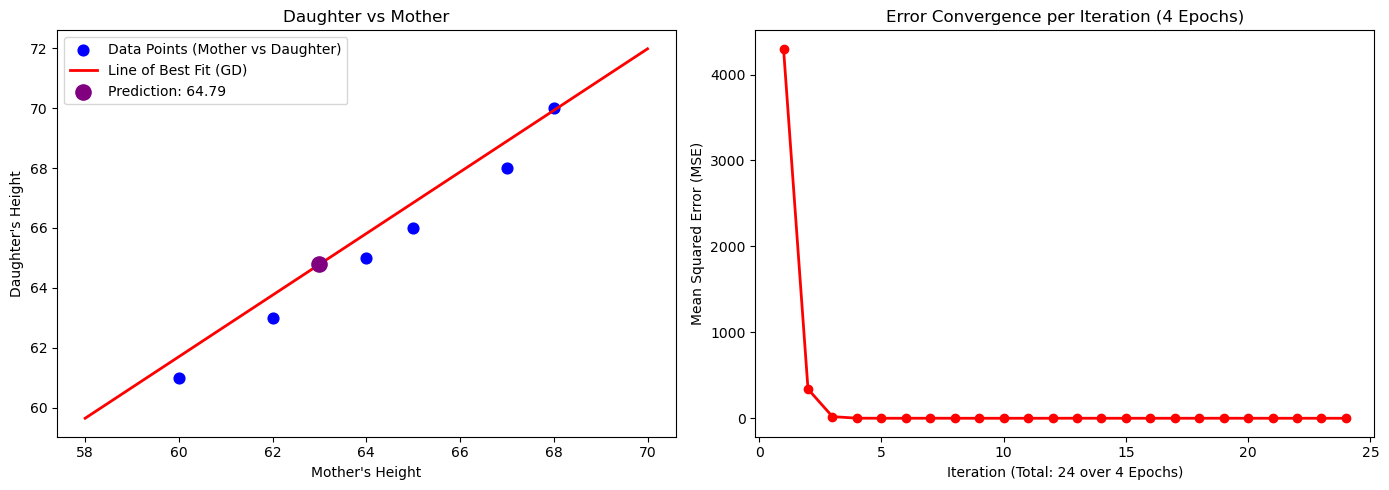

In [145]:
plt.figure(figsize=(14, 5))
# Daughter Height vs Mother Height
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', label='Data Points (Mother vs Daughter)', s=60)
X_line = np.linspace(58, 70, 100)
Y_line_gd = w * X_line + b
plt.plot(X_line, Y_line_gd, color='red', linewidth=2, label='Line of Best Fit (GD)')
plt.scatter([63], [pred_gd], color='purple', s=120, zorder=5, label=f'Prediction: {pred_gd:.2f}')
plt.xlabel("Mother's Height")
plt.ylabel("Daughter's Height")
plt.title("Daughter vs Mother")
plt.legend()

# Error vs Iteration (4 Epochs,24 Iterations)
plt.subplot(1, 2, 2)
plt.plot(history_iterations, history_errors, marker='o', color='red', linewidth=2)
plt.xlabel("Iteration (Total: 24 over 4 Epochs)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Error Convergence per Iteration (4 Epochs)")

plt.tight_layout()
plt.savefig('regression_plots.png')
plt.show()

2.<br>Create a CSV file for the above training data and write a Python function program to find the fitted logistic
regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with
your program. Compute the predicted y and assign the class label (prediction = 0 IF p(fail) < 0.5 and prediction
= 1 IF p(pass) >= 0.5) and compute the accuracy. Find the error for each iteration and predict the probability
that a student will pass the exam if they study for <br>
a) 3.5 hours <br>
b) 7.5 hours.<br> Plot the graph of error in y-axis and iteration in x-axis with 3 epochs (8x3=24 iterations).

In [146]:
data = {
    'hours_of_study_x': [1, 2, 3, 4, 5, 6, 7, 8],
    'pass_y': [0, 0, 0, 0, 1, 1, 1, 1]
}
df = pd.DataFrame(data)
df.to_csv('study_pass_data.csv', index=False)

df = pd.read_csv('study_pass_data.csv')
X = df['hours_of_study_x'].values
Y = df['pass_y'].values
n_samples = len(X)
df

,hours_of_study_x,pass_y
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


In [147]:
def sigmoid(z):#logistic
    return 1 / (1 + np.exp(-z))

epochs = 3
learning_rate = 0.1
w = 0.0
b = 0.0

h_iter = []
h_errors = []

iteration_count = 0
for epoch in range(epochs):
    for i in range(n_samples):
        iteration_count += 1
        xi = X[i]
        yi = Y[i]
        
        z = w * xi + b
        p = sigmoid(z)
        
        all_z = w * X + b
        all_p = sigmoid(all_z)
        cost = -np.mean(Y * np.log(all_p + 1e-9) + (1 - Y) * np.log(1 - all_p + 1e-9))
        
        h_iter.append(iteration_count)
        h_errors.append(cost)
        
        dw = (p - yi) * xi
        db = (p - yi)
        
        w -= learning_rate * dw
        b -= learning_rate * db

print(f"Final GD w: {w}, b: {b}")

Final GD w: 0.4730137971217937, b: -0.2705761346120768


Sklearn w: 0.35177043622551346, b: -0.9958859111458294
Accuracy (GD model): 0.5
Probability of pass for 3.5 hours: 0.7998
Probability of pass for 7.5 hours: 0.9636


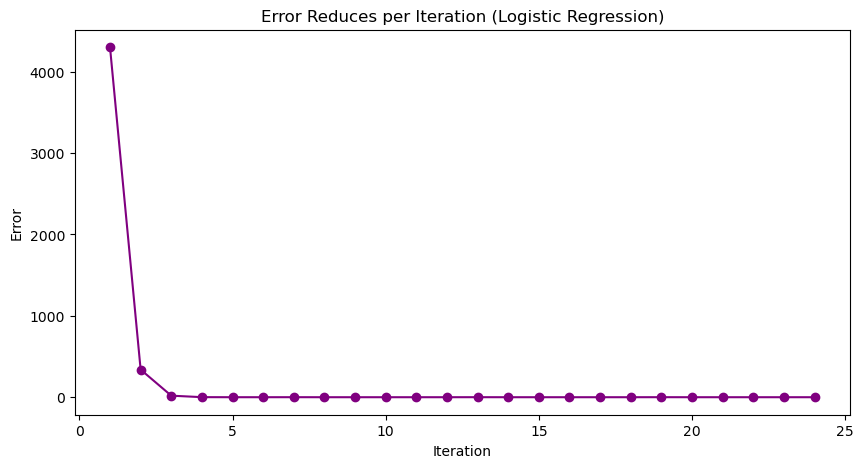

In [148]:
lr_model = LogisticRegression(solver='liblinear')
X_reshaped = X.reshape(-1, 1)
lr_model.fit(X_reshaped, Y)
sklearn_w = lr_model.coef_[0][0]
sklearn_b = lr_model.intercept_[0]

print(f"Sklearn w: {sklearn_w}, b: {sklearn_b}")

#GD
def predict_class(x, w, b):
    p = sigmoid(w * x + b)
    return 1 if p >= 0.5 else 0

predictions = [predict_class(x, w, b) for x in X]
accuracy = accuracy_score(Y, predictions)
print(f"Accuracy (GD model): {accuracy}")

#a
prob_3_5 = sigmoid(w * 3.5 + b)
#b
prob_7_5 = sigmoid(w * 7.5 + b)
print(f"Probability of pass for 3.5 hours: {round(prob_3_5, 4)}")
print(f"Probability of pass for 7.5 hours: {round(prob_7_5,4)}")

plt.figure(figsize=(10, 5))
plt.plot(history_iterations, history_errors, marker='o', color='purple', linestyle='-')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error Reduces per Iteration (Logistic Regression)')
plt.show()

3.<br>Consider the given dataset with two independent variables (X1 and X2) and a dependent variable (Y).
Implement in python, how you can perform the logistic regression to model the relationship between the
independent variables and the dependent variable.

In [149]:
data = [
    [4, 1, 2],
    [2, 8, -14],
    [1, 0, 1],
    [3, 2, -1],
    [1, 4, -7],
    [6, 7, -8]
]

df = pd.DataFrame(data, columns=['X1', 'X2', 'Y'])
df

,X1,X2,Y
0,4,1,2
1,2,8,-14
2,1,0,1
3,3,2,-1
4,1,4,-7
5,6,7,-8


In [150]:
X = df[['X1', 'X2']].values

Y_binary = np.where(df['Y'] > 0, 1, 0) # y becomes binary

model = LogisticRegression()
model.fit(X, Y_binary)
weights = model.coef_[0]
bias = model.intercept_[0]

print(f"Coefficients W (Weights for X1, X2): {weights}")
print(f"Intercept B (Bias): {bias}")

Coefficients W (Weights for X1, X2): [ 0.08482852 -0.94472563]
Intercept B (Bias): 1.331203102266646


In [151]:
predictions = model.predict(X)
accuracy = accuracy_score(Y_binary, predictions)

print(f"\nOriginal Y: {df['Y'].values}")
print(f"Binary Y  : {Y_binary}")
print(f"Predicted : {predictions}")
print(f"Accuracy  : {accuracy * 100:.2f}%")

new_sample = np.array([[3, 4]]) #new observation
predicted_prob = model.predict_proba(new_sample)[0]
predicted_class = model.predict(new_sample)[0]

print(f"\nPrediction for new sample [X1=3, X2=4]:")
print(f"Probability of Y=0: {predicted_prob[0]:.4f}")
print(f"Probability of Y=1: {predicted_prob[1]:.4f}")
print(f"Predicted Y: {predicted_class}")


Original Y: [  2 -14   1  -1  -7  -8]
Binary Y  : [1 0 1 0 0 0]
Predicted : [1 0 1 0 0 0]
Accuracy  : 100.00%

Prediction for new sample [X1=3, X2=4]:
Probability of Y=0: 0.8996
Probability of Y=1: 0.1004
Predicted Y: 0


# Addtionals

1.<br>Write a python program for SGD by considering the year wise gold and silver price data. Compare the
coefficients obtained from sklearn model with your program. Compute the error, MSE and RMSE. Predict the
gold price with the year 2025 for 1 gram and, gold and silver price with the year 2024 for 1 gram

In [163]:
data = {
    'Year': [2018, 2019, 2020, 2021, 2022, 2023],
    'Gold_Price_1g': [3119, 3702, 4872, 4800, 5273, 6062],
    'Silver_Price_1g': [2141, 2740, 3863, 3865, 4276, 5095]
}

df = pd.DataFrame(data)
X = df[['Year']].values
Y_gold = df['Gold_Price_1g'].values
Y_silver = df['Silver_Price_1g'].values
df

,Year,Gold_Price_1g,Silver_Price_1g
0,2018,3119,2141
1,2019,3702,2740
2,2020,4872,3863
3,2021,4800,3865
4,2022,5273,4276
5,2023,6062,5095


In [165]:
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

np.random.seed(42)
w_sgd = 0.0
b_sgd = 0.0
learning_rate = 0.05
epochs = 500
n_samples = len(X)

for epoch in range(epochs):
    for i in range(n_samples):
        xi = X_scaled[i][0]
        yi = Y_gold[i]

        pred = w_sgd * xi + b_sgd
        error = pred - yi

        dw = 2 * error * xi
        db = 2 * error
        
        w_sgd -= learning_rate * dw
        b_sgd -= learning_rate * db

w_sgd_original = w_sgd / X_std
b_sgd_original = b_sgd - (w_sgd * X_mean / X_std)

# sklearn models
# Gold Model
lr_gold = LinearRegression().fit(X, Y_gold)
sk_w_gold = lr_gold.coef_[0]
sk_b_gold = lr_gold.intercept_

# Silver Model
lr_silver = LinearRegression().fit(X, Y_silver)
sk_w_silver = lr_silver.coef_[0]
sk_b_silver = lr_silver.intercept_


In [166]:
# error calc
gold_preds = lr_gold.predict(X)
errors = Y_gold - gold_preds
mse = mean_squared_error(Y_gold, gold_preds)
rmse = np.sqrt(mse)

print("\nError in gold")
for i, yr in enumerate(df['Year']):
    print(f"Year {yr} - Actual: ₹{Y_gold[i]}, Predicted: ₹{gold_preds[i]:.2f}, Error: ₹{errors[i]:.2f}")
print(f"Mean Squared Error       (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")



Error in gold
Year 2018 - Actual: ₹3119, Predicted: ₹3255.43, Error: ₹-136.43
Year 2019 - Actual: ₹3702, Predicted: ₹3808.46, Error: ₹-106.46
Year 2020 - Actual: ₹4872, Predicted: ₹4361.49, Error: ₹510.51
Year 2021 - Actual: ₹4800, Predicted: ₹4914.51, Error: ₹-114.51
Year 2022 - Actual: ₹5273, Predicted: ₹5467.54, Error: ₹-194.54
Year 2023 - Actual: ₹6062, Predicted: ₹6020.57, Error: ₹41.43
Mean Squared Error       (MSE): 57207.91
Root Mean Squared Error (RMSE): 239.18


In [167]:
# sklearn predictions
pred_gold_2025 = lr_gold.predict([[2025]])[0]
pred_gold_2024 = lr_gold.predict([[2024]])[0]
pred_silver_2024 = lr_silver.predict([[2024]])[0]
pred_silver_2025 = lr_silver.predict([[2025]])[0]

print("Coefficient comparisin for Gold prediction between SGD and SKlearn")
print(f"Custom SGD Model: w= {w_sgd_original:.4f},  (b): {b_sgd_original:.4f}")
print(f"SK learn Model:   w= {sk_w_gold:.4f},  (b): {sk_b_gold:.4f}")


print("\n2024 and 2025 gold/silver predictions")
print(f"Predicted Gold Price (2025, 1g): ₹{pred_gold_2025:.2f}")
print(f"Predicted Gold Price (2024, 1g): ₹{pred_gold_2024:.2f}")
print(f"Predicted Silver Price (2024, 1g): ₹{pred_silver_2024:.2f}")
print(f"Predicted Silver Price (2025, 1g): ₹{pred_silver_2025:.2f}")

Coefficient comparisin for Gold prediction between SGD and SKlearn
Custom SGD Model: w= 549.2060,  (b): -1105027.6023
SK learn Model:   w= 553.0286,  (b): -1112756.2286

2024 and 2025 gold/silver predictions
Predicted Gold Price (2025, 1g): ₹7126.63
Predicted Gold Price (2024, 1g): ₹6573.60
Predicted Silver Price (2024, 1g): ₹5601.33
Predicted Silver Price (2025, 1g): ₹6155.05


2.<br> Suppose you have a gold/silver price dataset with a single independent variable (X) and a dependent variable
(Y). You want to fit a logistic regression model to this data. Develop an example code snippet in Python.

In [168]:
years = np.arange(2009, 2024)
gold_prices = [3119, 3250, 3500, 3702, 4100, 4370, 4500, 4872, 4600, 4800, 5000, 5273, 5800, 6062, 6300]

df = pd.DataFrame({'Year': years, 'Gold_Price': gold_prices})
X = df[['Year']].values  # Independent variable
df

,Year,Gold_Price
0,2009,3119
1,2010,3250
2,2011,3500
3,2012,3702
4,2013,4100
5,2014,4370
6,2015,4500
7,2016,4872
8,2017,4600
9,2018,4800


In [169]:
threshold = 4800
Y_binary = np.where(df['Gold_Price'] > threshold, 1, 0) #making binary - high/low

model = LogisticRegression()
model.fit(X, Y_binary)
w = model.coef_[0][0]
b = model.intercept_[0]
predictions = model.predict(X)
probabilities = model.predict_proba(X)[:, 1] # Probability of class 1
probabilities

array([0.40116244, 0.40111454, 0.40106664, 0.40101874, 0.40097084,
       0.40092294, 0.40087505, 0.40082715, 0.40077926, 0.40073137,
       0.40068348, 0.4006356 , 0.40058771, 0.40053983, 0.40049195])

In [170]:
accuracy = accuracy_score(Y_binary, predictions)

print(f"Logistic Regression Weight (w): {w:.4f}")
print(f"Logistic Regression Bias (b): {b:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nPredictions vs Actual Binary Classes:")
for i, x_val in enumerate(df['Year']):
    print(f"Year {x_val} -> Actual: {Y_binary[i]},"
          f"Predicted: {predictions[i]},"
          f"Pass Probability: {probabilities[i]:.4f}")


Logistic Regression Weight (w): -0.0002
Logistic Regression Bias (b): -0.0000
Accuracy: 60.00%

Predictions vs Actual Binary Classes:
Year 2009 -> Actual: 0,Predicted: 0,Pass Probability: 0.4012
Year 2010 -> Actual: 0,Predicted: 0,Pass Probability: 0.4011
Year 2011 -> Actual: 0,Predicted: 0,Pass Probability: 0.4011
Year 2012 -> Actual: 0,Predicted: 0,Pass Probability: 0.4010
Year 2013 -> Actual: 0,Predicted: 0,Pass Probability: 0.4010
Year 2014 -> Actual: 0,Predicted: 0,Pass Probability: 0.4009
Year 2015 -> Actual: 0,Predicted: 0,Pass Probability: 0.4009
Year 2016 -> Actual: 1,Predicted: 0,Pass Probability: 0.4008
Year 2017 -> Actual: 0,Predicted: 0,Pass Probability: 0.4008
Year 2018 -> Actual: 0,Predicted: 0,Pass Probability: 0.4007
Year 2019 -> Actual: 1,Predicted: 0,Pass Probability: 0.4007
Year 2020 -> Actual: 1,Predicted: 0,Pass Probability: 0.4006
Year 2021 -> Actual: 1,Predicted: 0,Pass Probability: 0.4006
Year 2022 -> Actual: 1,Predicted: 0,Pass Probability: 0.4005
Year 2023 ->

In [171]:
new_year = np.array([[2025]])
pred_class = model.predict(new_year)[0]
pred_prob = model.predict_proba(new_year)[0][1]

print(f"\n2025 Prediction:")
print(f"Predicted Class: {pred_class}")
print(f"Probability of being above threshold: {pred_prob:.4f}")


2025 Prediction:
Predicted Class: 0
Probability of being above threshold: 0.4004
